In [2]:
# ! uv pip install yfinance

In [ ]:
import sys, statsmodels, statsmodels.api as sm
print(sys.executable, statsmodels.__version__)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
print("statsmodels OK")

In [6]:
import pandas as pd, numpy as np, yfinance as yf

ASSETS = ['BTC-USD','ETH-USD','SOL-USD']
start = '2020-01-01'

df_px = yf.download(ASSETS, start=start, auto_adjust=True)['Close'].dropna()
df_px.columns = [c.split('-')[0] for c in df_px.columns]  # BTC, ETH, SOL
df_ret = np.log(df_px).diff().dropna()                     # log returns


[*********************100%***********************]  3 of 3 completed


In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

H = 7
btc = df_px['BTC']
ret = df_ret['BTC']

# Forecast returns
model = SARIMAX(ret, order=(1,0,0), enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False)
fc_ret = res.get_forecast(H).predicted_mean.values

# Convert returns to price
btc_last = btc.iloc[-1]
fc_price = [btc_last]
for r in fc_ret:
    fc_price.append(fc_price[-1]*np.exp(r))
fc_price = np.array(fc_price[1:])

# Constraint enforcement
max_ramp = 0.15
lo_band, hi_band = 0.7*btc_last, 1.3*btc_last
fc_price_con = [btc_last]
for p in fc_price:
    p_c = min(max(p, fc_price_con[-1]*(1-max_ramp)), fc_price_con[-1]*(1+max_ramp))
    p_c = min(max(p_c, lo_band), hi_band)
    fc_price_con.append(p_c)
fc_price_con = np.array(fc_price_con[1:])


In [8]:
ref_n, live_n = 90, 30
eth, sol = df_ret['ETH'], df_ret['SOL']

ref_eth = eth.tail(ref_n+live_n).head(ref_n)
ref_sol = sol.tail(ref_n+live_n).head(ref_n)

def robust_z(x):
    med = np.median(x)
    mad = np.median(np.abs(x-med)) + 1e-12
    return (x - med)/(1.4826*mad)

thr_eth = np.percentile(np.abs(robust_z(ref_eth.values)), 97)
thr_sol = np.percentile(np.abs(robust_z(ref_sol.values)), 97)

live_eth, live_sol = eth.tail(live_n), sol.tail(live_n)
flag_eth = (np.abs(robust_z(live_eth.values)) > thr_eth).astype(int)
flag_sol = (np.abs(robust_z(live_sol.values)) > thr_sol).astype(int)

anomaly_score = (flag_eth + flag_sol).mean()  # 0..2


In [9]:
import numpy as np
import pandas as pd

def robust_z(x: np.ndarray) -> np.ndarray:
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    mad = mad if mad > 0 else 1e-12  # avoid divide-by-zero
    return (x - med) / (1.4826 * mad)

def compute_anomaly_score(df_ret: pd.DataFrame, ref_n: int = 90, live_n: int = 30):
    eth = pd.to_numeric(df_ret['ETH'], errors='coerce')
    sol = pd.to_numeric(df_ret['SOL'], errors='coerce')

    # require enough non-NaN data
    assert eth.dropna().shape[0] >= ref_n + live_n and sol.dropna().shape[0] >= ref_n + live_n, \
        "Not enough data for ref+live windows"

    eth_tail = eth.tail(ref_n + live_n)
    sol_tail = sol.tail(ref_n + live_n)

    ref_eth = eth_tail.head(ref_n).to_numpy()
    ref_sol = sol_tail.head(ref_n).to_numpy()
    live_eth = eth_tail.tail(live_n).to_numpy()
    live_sol = sol_tail.tail(live_n).to_numpy()

    thr_eth = np.nanpercentile(np.abs(robust_z(ref_eth)), 97)
    thr_sol = np.nanpercentile(np.abs(robust_z(ref_sol)), 97)

    z_eth_live = np.abs(robust_z(live_eth))
    z_sol_live = np.abs(robust_z(live_sol))

    flag_eth = (z_eth_live > thr_eth).astype(int)
    flag_sol = (z_sol_live > thr_sol).astype(int)

    anomaly_score = (flag_eth + flag_sol).mean()  # scalar in [0, 2]

    return {
        "thr_eth": float(thr_eth),
        "thr_sol": float(thr_sol),
        "flag_eth": flag_eth,   # length live_n
        "flag_sol": flag_sol,   # length live_n
        "anomaly_score": float(anomaly_score)
    }

# usage
res = compute_anomaly_score(df_ret, ref_n=90, live_n=30)
print(res["anomaly_score"])

0.1


In [10]:
def sharpe(r, rf=0.0): return (r.mean()-rf)/(r.std()+1e-12)
def sortino(r, rf=0.0):
    d = r[r<0].std() + 1e-12
    return (r.mean()-rf)/d if d>0 else np.inf
def max_drawdown(prices):
    rollmax = np.maximum.accumulate(prices)
    return (prices/rollmax - 1.0).min()


In [11]:
weights = {
    'BTC_only': np.array([1.0,0.0,0.0]),
    'BTC_ETH':  np.array([0.6,0.4,0.0]),
    'All3':     np.array([0.5,0.3,0.2])
}
hist_r = df_ret.tail(180)
perf = []
for name, w in weights.items():
    pr = hist_r.values @ w
    perf.append({'name':name, 'sharpe':sharpe(pr), 'sortino':sortino(pr), 'mdd':max_drawdown((1+pr).cumprod())})
perf = pd.DataFrame(perf).set_index('name')

hi_anomaly = anomaly_score > 0.25
if hi_anomaly:
    choice = perf.sort_values(['mdd','sharpe'], ascending=[True,False]).index[0]
else:
    feasible = perf[perf['mdd']>=-0.35]
    choice = feasible.sort_values('sharpe', ascending=False).index[0] if not feasible.empty else perf.sort_values('sharpe', ascending=False).index[0]

print('Anomaly score:', round(anomaly_score,3))
print('Portfolio metrics:\n', perf.round(3))
print('Chosen portfolio:', choice)


Anomaly score: 0.1
Portfolio metrics:
           sharpe  sortino    mdd
name                            
BTC_only   0.083    0.135 -0.133
BTC_ETH    0.107    0.169 -0.205
All3       0.100    0.161 -0.215
Chosen portfolio: BTC_ETH


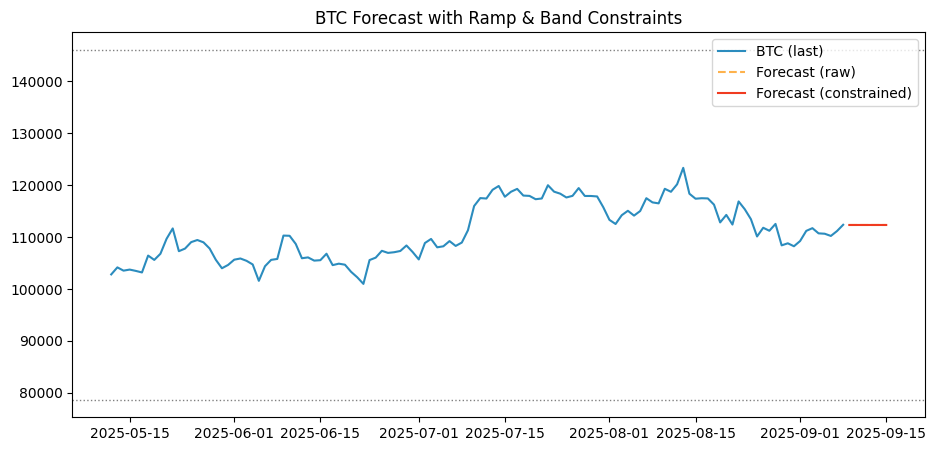

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,5))
lastN = 120
btc_tail = btc.tail(lastN)
ax.plot(btc_tail.index, btc_tail.values, label='BTC (last)', color='#2b8cbe')

future_idx = pd.date_range(btc.index[-1]+pd.Timedelta(days=1), periods=H, freq='D')
ax.plot(future_idx, fc_price, '--', color='#feb24c', label='Forecast (raw)')
ax.plot(future_idx, fc_price_con, '-', color='#f03b20', label='Forecast (constrained)')

ax.axhline(lo_band, color='grey', ls=':', lw=1)
ax.axhline(hi_band, color='grey', ls=':', lw=1)
ax.set_title('BTC Forecast with Ramp & Band Constraints')
ax.legend(); plt.show()
